#1. Setup and Dependencies


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install ultralytics adversarial-robustness-toolbox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 71.3 MB/s eta 0:00:00


In [3]:
import os
import cv2
import numpy as np
import random
from ultralytics import YOLO
from tqdm import tqdm
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# 2. Load Model and Dataset

In [ ]:
model_path = '/content/drive/MyDrive/blood_cell_project/yolov10m_combined.pt'
test_images_dir = '/content/drive/MyDrive/blood_cell_project/BCCD_TXL_combined/combined_dataset/images/test'
test_labels_dir = '/content/drive/MyDrive/blood_cell_project/BCCD_TXL_combined/combined_dataset/labels/test'
output_image_dir = '/content/drive/MyDrive/blood_cell_project/patch_visualizations/yolov10m'
os.makedirs(output_image_dir, exist_ok=True)

In [ ]:
model = YOLO(model_path)

# Final optimised thresholds (from earlier)
THRESHOLDS = {0: 0.76,   # RBC
              1: 0.40,   # WBC
              2: 0.56}   # Platelets

# 3. Define Helper Functions

In [ ]:
patch_size = (160, 160)

gray_patch = np.full((*patch_size, 3), (195, 204, 196), dtype=np.uint8)
white_patch = np.full((*patch_size, 3), 255, dtype=np.uint8)
black_patch = np.full((*patch_size, 3), 0, dtype=np.uint8)
dummy_patch = np.zeros((1,1,3), dtype=np.uint8)

def create_shaky_patch(img, patch_size=(160,160), blur_ksize=(25,25), sigma=15):
    h, w = img.shape[:2]
    ph, pw = patch_size
    if ph > h or pw > w:
        ph = min(ph, h)
        pw = min(pw, w)
    max_x = w - pw
    max_y = h - ph
    if max_x < 0 or max_y < 0:
        crop = cv2.resize(img, (pw, ph))
    else:
        x = random.randint(0, max_x)
        y = random.randint(0, max_y)
        crop = img[y:y+ph, x:x+pw]
    blurred = cv2.GaussianBlur(crop, blur_ksize, sigma)
    return blurred


In [ ]:
def evaluate_with_patch(model, thresholds, test_images_dir, test_labels_dir,
                        patch=None, is_shaky=False, num_placements=10,
                        save_examples=False, output_dir=None, patch_name='patch'):
    """
    Evaluate counting accuracy.
    - patch = None -> clean baseline
    - patch = numpy array -> solid patch
    - is_shaky = True -> generate shaky patch per image (ignores patch argument)
    - save_examples = True -> save original and one patched image for first 3 test images
    """
    if save_examples and output_dir is None:
        raise ValueError("output_dir must be provided when save_examples=True")
    if save_examples:
        os.makedirs(output_dir, exist_ok=True)

    total_gt = {0:0, 1:0, 2:0}
    total_pred = {0:0, 1:0, 2:0}
    class_names = ['RBC', 'WBC', 'Platelets']

    # Determine which images to save examples for
    all_images = [f for f in os.listdir(test_images_dir) if f.endswith(('.jpg','.png'))]
    example_images = all_images[:3] if save_examples else []

    for img_idx, img_file in enumerate(tqdm(all_images, desc=f"Evaluating {patch_name}")):
        # Ground truth
        label_file = img_file.replace('.jpg','.txt').replace('.png','.txt')
        label_path = os.path.join(test_labels_dir, label_file)
        gt_counts = {0:0,1:0,2:0}
        if os.path.exists(label_path):
            with open(label_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    cls = int(parts[0])
                    gt_counts[cls] += 1

        # Load original image
        img_path = os.path.join(test_images_dir, img_file)
        img_orig = cv2.imread(img_path)
        if img_orig is None:
            continue

        # Save original image for examples (if needed)
        if save_examples and img_file in example_images:
            orig_rgb = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
            plt.imsave(os.path.join(output_dir, f'{patch_name}_original_{img_file}.png'), orig_rgb)

        # Clean baseline (no patch)
        if patch is None and not is_shaky:
            results = model(img_orig, verbose=False)
            pred_counts = {0:0,1:0,2:0}
            if len(results[0].boxes) > 0:
                cls = results[0].boxes.cls.cpu().numpy()
                conf = results[0].boxes.conf.cpu().numpy()
                for c in [0,1,2]:
                    mask = (cls == c) & (conf > thresholds[c])
                    pred_counts[c] = np.sum(mask)
            for c in [0,1,2]:
                total_gt[c] += gt_counts[c]
                total_pred[c] += pred_counts[c]
        else:
            # Patch evaluation
            if is_shaky:
                patch_img = create_shaky_patch(img_orig, patch_size=(160,160), blur_ksize=(25,25), sigma=15)
            else:
                patch_img = patch
            patch_img = cv2.resize(patch_img, (160,160))
            ph, pw = patch_img.shape[:2]

            # For each placement, overlay and infer
            pred_counts_per_placement = []
            for placement_idx in range(num_placements):
                # Resize to fixed size for overlay (YOLO will resize internally)
                img_resized = cv2.resize(img_orig, (640,640))
                h, w = img_resized.shape[:2]
                if pw > w or ph > h:
                    patch_resized = cv2.resize(patch_img, (w, h))
                    ph, pw = patch_resized.shape[:2]
                    x, y = 0, 0
                else:
                    patch_resized = patch_img
                    x = random.randint(0, w - pw)
                    y = random.randint(0, h - ph)
                img_patched = img_resized.copy()
                img_patched[y:y+ph, x:x+pw] = patch_resized

                # Save one patched example (first placement of the first example image)
                if save_examples and img_file in example_images and placement_idx == 0:
                    patched_rgb = cv2.cvtColor(img_patched, cv2.COLOR_BGR2RGB)
                    plt.imsave(os.path.join(output_dir, f'{patch_name}_patched_{img_file}.png'), patched_rgb)

                results = model(img_patched, verbose=False)
                pred_counts = {0:0,1:0,2:0}
                if len(results[0].boxes) > 0:
                    cls = results[0].boxes.cls.cpu().numpy()
                    conf = results[0].boxes.conf.cpu().numpy()
                    for c in [0,1,2]:
                        mask = (cls == c) & (conf > thresholds[c])
                        pred_counts[c] = np.sum(mask)
                pred_counts_per_placement.append(pred_counts)

            avg_pred_counts = {c: np.mean([p[c] for p in pred_counts_per_placement]) for c in [0,1,2]}
            for c in [0,1,2]:
                total_gt[c] += gt_counts[c]
                total_pred[c] += avg_pred_counts[c]

    # Compute accuracies
    accuracies = {}
    for c, name in enumerate(class_names):
        gt = total_gt[c]
        pred = total_pred[c]
        if gt > 0:
            acc = (1 - abs(pred - gt) / gt) * 100
        else:
            acc = 0.0
        accuracies[name] = acc
    return accuracies


In [ ]:
def display_patch_comparisons(image_dir):

    files = os.listdir(image_dir)
    # Group by patch type (gray, white, black, shaky)
    patch_types = ['gray', 'white', 'black', 'shaky']

    for ptype in patch_types:
        # Find all original images for this patch type
        orig_files = [f for f in files if f.startswith(f'{ptype}_original_')]
        if not orig_files:
            print(f"No images found for {ptype} patch.")
            continue

        # Take the first one as example
        orig_file = orig_files[0]
        # Derive the corresponding patched file name
        base = orig_file.replace(f'{ptype}_original_', '')
        patched_file = f'{ptype}_patched_{base}'

        if patched_file not in files:
            print(f"Patched image not found for {ptype}: {patched_file}")
            continue

        # Load images
        orig_path = os.path.join(image_dir, orig_file)
        patched_path = os.path.join(image_dir, patched_file)
        img_orig = cv2.imread(orig_path)
        img_patch = cv2.imread(patched_path)
        if img_orig is None or img_patch is None:
            print(f"Could not load images for {ptype}")
            continue

        # Convert BGR to RGB
        img_orig_rgb = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
        img_patch_rgb = cv2.cvtColor(img_patch, cv2.COLOR_BGR2RGB)

        # Display side‑by‑side
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(img_orig_rgb)
        axes[0].set_title(f'Original – {ptype.capitalize()} patch')
        axes[0].axis('off')
        axes[1].imshow(img_patch_rgb)
        axes[1].set_title(f'Patched – {ptype.capitalize()} patch')
        axes[1].axis('off')
        plt.suptitle(f'Comparison for {ptype.capitalize()} patch')
        plt.tight_layout()
        plt.show()

# 4. Clean Baseline and Plain Patch Evaluation

In [ ]:
# Clean baseline (no patch, no images saved)
clean_acc = evaluate_with_patch(model, THRESHOLDS, test_images_dir, test_labels_dir,
                                patch=None, save_examples=False)

# Gray patch
gray_acc = evaluate_with_patch(model, THRESHOLDS, test_images_dir, test_labels_dir,
                               patch=gray_patch, save_examples=True,
                               output_dir=output_image_dir, patch_name='gray')

# White patch
white_acc = evaluate_with_patch(model, THRESHOLDS, test_images_dir, test_labels_dir,
                                patch=white_patch, save_examples=True,
                                output_dir=output_image_dir, patch_name='white')

# Black patch
black_acc = evaluate_with_patch(model, THRESHOLDS, test_images_dir, test_labels_dir,
                                patch=black_patch, save_examples=True,
                                output_dir=output_image_dir, patch_name='black')

# Shaky patch
shaky_acc = evaluate_with_patch(model, THRESHOLDS, test_images_dir, test_labels_dir,
                                is_shaky=True, save_examples=True,
                                output_dir=output_image_dir, patch_name='shaky')


Evaluating shaky: 100%|██████████| 60/60 [08:24<00:00,  8.41s/it]


# 5. Comparion Table

In [ ]:
# Print comparison table
print("\n" + "="*70)
print("COMPARISON: Clean Baseline vs. Plain Patches (random placement, N=10)")
print("="*70)
print(f"{'Patch Type':<20} {'RBC Acc':>10} {'WBC Acc':>10} {'PLT Acc':>10}")
print("-"*70)
print(f"{'Clean':<20} {clean_acc['RBC']:9.2f}% {clean_acc['WBC']:9.2f}% {clean_acc['Platelets']:9.2f}%")
print(f"{'Gray (196,204,195)':<20} {gray_acc['RBC']:9.2f}% {gray_acc['WBC']:9.2f}% {gray_acc['Platelets']:9.2f}%")
print(f"{'White':<20} {white_acc['RBC']:9.2f}% {white_acc['WBC']:9.2f}% {white_acc['Platelets']:9.2f}%")
print(f"{'Black':<20} {black_acc['RBC']:9.2f}% {black_acc['WBC']:9.2f}% {black_acc['Platelets']:9.2f}%")
print(f"{'Shaky (blurred crop)':<20} {shaky_acc['RBC']:9.2f}% {shaky_acc['WBC']:9.2f}% {shaky_acc['Platelets']:9.2f}%")



COMPARISON: Clean Baseline vs. Plain Patches (random placement, N=10)
Patch Type              RBC Acc    WBC Acc    PLT Acc
----------------------------------------------------------------------
Clean                    94.80%     98.36%     95.65%
Gray (196,204,195)       65.10%     93.93%     83.77%
White                    64.00%     90.82%     82.61%
Black                    63.67%     89.67%     82.61%
Shaky (blurred crop)     64.61%     92.62%     88.55%


# 6. Visualisation

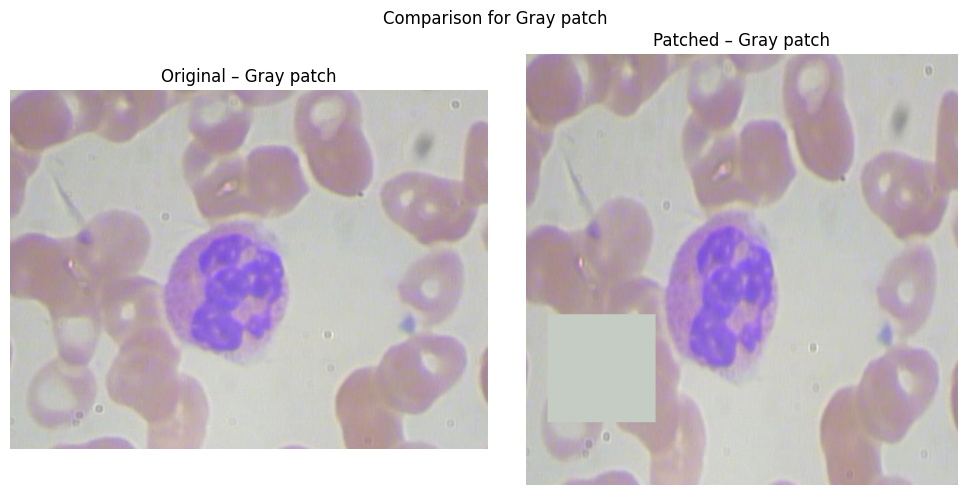

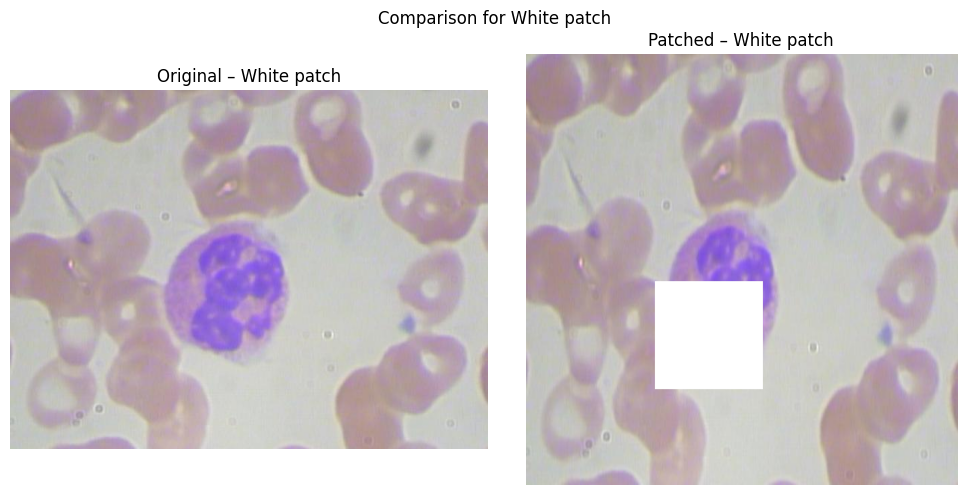

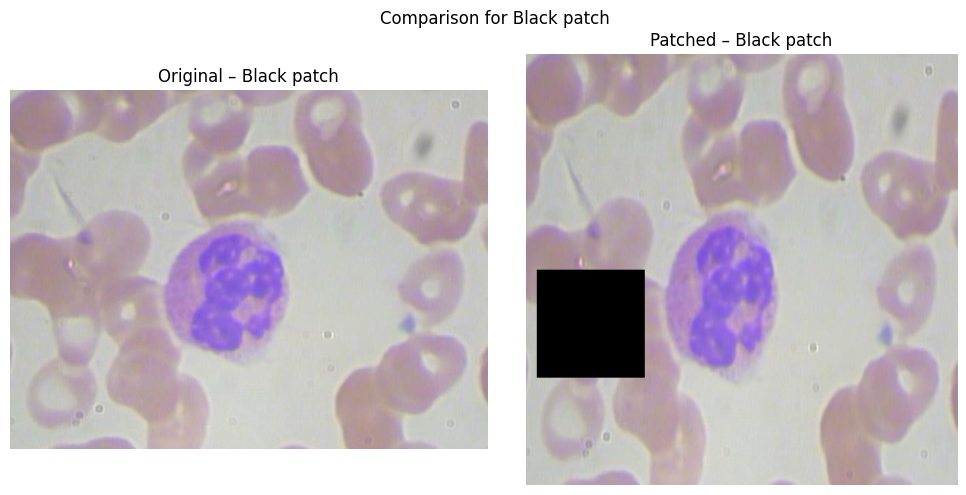

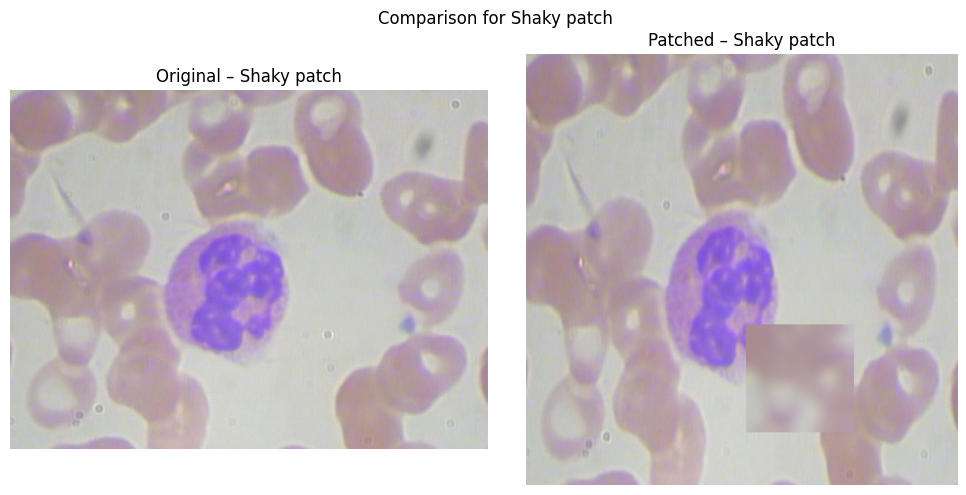

In [ ]:
image_dir = '/content/drive/MyDrive/blood_cell_project/patch_visualizations/yolov10m'
display_patch_comparisons(image_dir)